# Lesson 2: Hypothesis Testing, Statistical Significance, and Experimental Design

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
Campbell University, Lundy-Fetterman School of Business  
**Instructor:** Matthew L. Kelly, PhD

## Where this fits in the seven-lecture series

1. **Probability distributions and descriptive statistics**  
2. **Hypothesis testing, statistical significance, and experimental design**  
3. Confidence intervals, estimation, and sampling distributions  
4. Regression analysis and causal interpretation  
5. Time series, stationarity, and forecasting  
6. Classification, prediction, and model evaluation  
7. Applied econometric projects in finance, accounting, and economics

This second lecture turns the descriptive ideas from Lesson 1 into a decision framework. In Lesson 1, we learned how to describe random variables and distributions. In this lecture, we ask a more inferential question: **when observed data differ from a benchmark, is that difference probably meaningful, or could it plausibly arise from sampling variation?**

## Learning objectives

By the end of this notebook, you should be able to:

1. State a null hypothesis and an alternative hypothesis.
2. Compute and interpret a test statistic.
3. Explain the role of the standard error.
4. Interpret a p-value without overstating what it means.
5. Distinguish Type I errors, Type II errors, and statistical power.
6. Use one-sample, two-sample, paired, chi-square, ANOVA, and non-parametric tests.
7. Check important assumptions: normality, stationarity, and independence.
8. Use power analysis to plan an experiment.
9. Understand how a simple Bayesian comparison differs from classical hypothesis testing.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Classical hypothesis tests and probability distributions
from scipy import stats
from scipy.stats import (
    ttest_1samp,
    ttest_ind,
    ttest_rel,
    chi2_contingency,
    f_oneway,
    kruskal,
    mannwhitneyu,
    norm,
    beta,
)

# Post-hoc testing, power analysis, and stationarity testing
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import TTestIndPower
from statsmodels.tsa.stattools import adfuller

# Reproducibility
rng = np.random.default_rng(42)

# Plot defaults
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# 1. The logic of hypothesis testing

A hypothesis test begins with a benchmark model of the world. That benchmark is the **null hypothesis**, usually written as $H_0$. The competing claim is the **alternative hypothesis**, usually written as $H_1$ or $H_A$.

For example, suppose we observe the heights of ten students and want to know whether the mean height differs from 5.8 feet. The hypotheses are:

$$
H_0: \mu = 5.8
$$

$$
H_1: \mu \neq 5.8
$$

The basic sequence is:

1. Define $H_0$ and $H_1$.
2. Choose a significance level $\alpha$, commonly $0.05$.
3. Compute a test statistic.
4. Compute a p-value.
5. Reject or fail to reject $H_0$.

A hypothesis test does **not** usually prove that a hypothesis is true. It asks whether the observed evidence is unusually far from what the null hypothesis predicts.

# 2. One-sample t-test

Suppose the population mean under the null is $\mu_0$. For a sample $x_1, x_2, \ldots, x_n$, the sample mean is:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

The sample standard deviation is:

$$
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

The **standard error** of the sample mean is:

$$
SE(\bar{x}) = \frac{s}{\sqrt{n}}
$$

The one-sample t-statistic is:

$$
t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}
$$

The t-statistic measures the difference between the sample mean and the null-hypothesized mean in standard-error units.

In [3]:
# Example: testing whether average height differs from 5.8 feet
heights = np.array([5.5, 5.7, 5.8, 5.9, 6.0, 5.6, 5.8, 5.7, 5.9, 5.8])
mu_0 = 5.8
alpha = 0.05

# Built-in one-sample t-test
t_stat, p_value = ttest_1samp(heights, popmean=mu_0)

print(f"Sample mean: {heights.mean():.4f}")
print(f"Null-hypothesized mean: {mu_0:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < alpha:
    print("Decision: reject H0.")
else:
    print("Decision: fail to reject H0.")

Sample mean: 5.7700
Null-hypothesized mean: 5.8000
T-statistic: -0.6348
P-value: 0.5414
Decision: fail to reject H0.


## Manual calculation

The built-in function is useful, but the formula matters. We can compute the same t-statistic directly:

$$
t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}
$$

In [5]:
sample_mean = np.mean(heights)
sample_std = np.std(heights, ddof=1)
n = len(heights)
standard_error = sample_std / np.sqrt(n)
t_stat_manual = (sample_mean - mu_0) / standard_error

print(f"Sample mean: {sample_mean:.4f}")
print(f"Sample standard deviation: {sample_std:.4f}")
print(f"Standard error: {standard_error:.4f}")
print(f"Manual t-statistic: {t_stat_manual:.4f}")

Sample mean: 5.7700
Sample standard deviation: 0.1494
Standard error: 0.0473
Manual t-statistic: -0.6348


# 3. P-values and critical regions

A p-value is the probability, under the null hypothesis, of observing a test statistic at least as extreme as the one we actually observed.

For a two-sided z-test, the rejection rule at the 5% level is approximately:

$$
\text{Reject } H_0 \quad \text{if} \quad |z| > 1.96
$$

Equivalently, reject when:

$$
p\text{-value} < \alpha
$$

A p-value is **not** the probability that $H_0$ is true. It is a probability statement about the data, conditional on the null hypothesis.

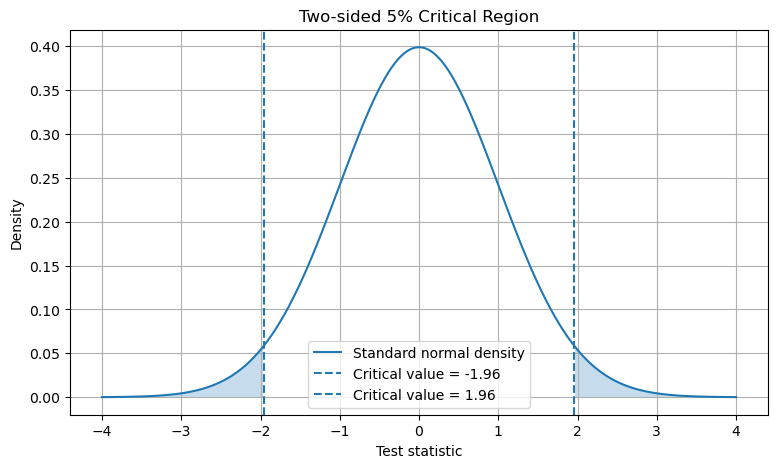

In [7]:
# Visualizing the critical region for a two-sided 5% z-test
x = np.linspace(-4, 4, 1000)
pdf = norm.pdf(x)
critical_value = norm.ppf(1 - alpha / 2)

plt.figure(figsize=(9, 5))
plt.plot(x, pdf, label="Standard normal density")
plt.axvline(-critical_value, linestyle="--", label=f"Critical value = {-critical_value:.2f}")
plt.axvline(critical_value, linestyle="--", label=f"Critical value = {critical_value:.2f}")
plt.fill_between(x, 0, pdf, where=(x <= -critical_value) | (x >= critical_value), alpha=0.25)
plt.title("Two-sided 5% Critical Region")
plt.xlabel("Test statistic")
plt.ylabel("Density")
plt.legend()
plt.show()

# 4. Type I errors, Type II errors, and power

Classical hypothesis testing has two main error types:

| Decision | Reality: $H_0$ true | Reality: $H_0$ false |
|---|---:|---:|
| Reject $H_0$ | Type I error | Correct rejection |
| Fail to reject $H_0$ | Correct non-rejection | Type II error |

The significance level $\alpha$ controls the probability of a Type I error:

$$
\alpha = P(\text{Reject } H_0 \mid H_0 \text{ is true})
$$

The probability of a Type II error is $\beta$:

$$
\beta = P(\text{Fail to reject } H_0 \mid H_0 \text{ is false})
$$

Statistical power is:

$$
\text{Power} = 1 - \beta
$$

Power is the probability that a test detects an effect when the effect really exists.

# 5. Common hypothesis tests

Different research designs call for different tests. This section shows the most common tests used in introductory applied statistics and econometrics.

## 5.1 Independent two-sample t-test

Use an independent two-sample t-test when comparing the means of two independent groups:

$$
H_0: \mu_1 = \mu_2
$$

$$
H_1: \mu_1 \neq \mu_2
$$

In [9]:
group_1 = np.array([85, 87, 89, 90, 88])
group_2 = np.array([80, 81, 85, 86, 83])

t_stat, p_value = ttest_ind(group_1, group_2, equal_var=False)  # Welch's t-test

print(f"Group 1 mean: {group_1.mean():.2f}")
print(f"Group 2 mean: {group_2.mean():.2f}")
print(f"Welch two-sample t-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Group 1 mean: 87.80
Group 2 mean: 83.00
Welch two-sample t-statistic: 3.3607
P-value: 0.0110


## 5.2 Paired t-test

Use a paired t-test when observations are naturally matched: before/after, twin studies, repeated measurements, or the same firm observed under two treatments.

Let $d_i$ be the paired difference for unit $i$. The test is equivalent to a one-sample t-test on the differences:

$$
H_0: \mu_d = 0
$$

In [11]:
before = np.array([85, 87, 89, 90, 88])
after = np.array([87, 88, 90, 91, 89])

t_stat, p_value = ttest_rel(before, after)

print(f"Mean before: {before.mean():.2f}")
print(f"Mean after: {after.mean():.2f}")
print(f"Mean difference: {(after - before).mean():.2f}")
print(f"Paired t-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Mean before: 87.80
Mean after: 89.00
Mean difference: 1.20
Paired t-statistic: -6.0000
P-value: 0.0039


## 5.3 Chi-square test of independence

A chi-square test is used with categorical data. It asks whether two categorical variables are statistically independent.

For observed counts $O_{ij}$ and expected counts $E_{ij}$, the statistic is:

$$
\chi^2 = \sum_i \sum_j \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

In [13]:
# Example contingency table: rows might be two groups; columns might be two preferences
observed = np.array([[50, 30], [20, 100]])
chi2_stat, p_value, dof, expected = chi2_contingency(observed)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")
print("\nExpected frequencies under independence:")
print(pd.DataFrame(expected, columns=["Preference A", "Preference B"], index=["Group 1", "Group 2"]))

Chi-square statistic: 42.3306
Degrees of freedom: 1
P-value: 0.0000

Expected frequencies under independence:
         Preference A  Preference B
Group 1          28.0          52.0
Group 2          42.0          78.0


# 6. Comparing more than two groups: ANOVA

A t-test compares two means. **Analysis of variance**, or ANOVA, compares three or more means.

For one-way ANOVA:

$$
H_0: \mu_1 = \mu_2 = \cdots = \mu_k
$$

$$
H_1: \text{At least one group mean differs.}
$$

The ANOVA test statistic is an F-statistic:

$$
F = \frac{\text{between-group variation}}{\text{within-group variation}}
$$

A large F-statistic indicates that group means differ more than we would expect from within-group noise alone.

In [15]:
anova_group_1 = np.array([85, 88, 86, 90, 87])
anova_group_2 = np.array([80, 82, 83, 81, 84])
anova_group_3 = np.array([78, 76, 79, 77, 75])

f_stat, p_value = f_oneway(anova_group_1, anova_group_2, anova_group_3)

print(f"One-way ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

One-way ANOVA F-statistic: 44.8506
P-value: 0.0000


## Post-hoc comparisons: Tukey's HSD

ANOVA tells us whether at least one mean differs. It does not tell us which groups differ. If ANOVA rejects $H_0$, a post-hoc test such as Tukey's HSD can compare pairs of group means while controlling the multiple-comparisons problem.

In [17]:
tukey_data = pd.DataFrame({
    "Value": np.concatenate([anova_group_1, anova_group_2, anova_group_3]),
    "Group": (["Group 1"] * len(anova_group_1)
              + ["Group 2"] * len(anova_group_2)
              + ["Group 3"] * len(anova_group_3))
})

tukey = pairwise_tukeyhsd(endog=tukey_data["Value"], groups=tukey_data["Group"], alpha=0.05)
print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
Group 1 Group 2     -5.2 0.0011  -8.0734 -2.3266   True
Group 1 Group 3    -10.2    0.0 -13.0734 -7.3266   True
Group 2 Group 3     -5.0 0.0015  -7.8734 -2.1266   True
-------------------------------------------------------


C:\Users\mlkelly0906\AppData\Local\Temp\ipykernel_35312\2014521903.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([anova_group_1, anova_group_2, anova_group_3], labels=["Group 1", "Group 2", "Group 3"])


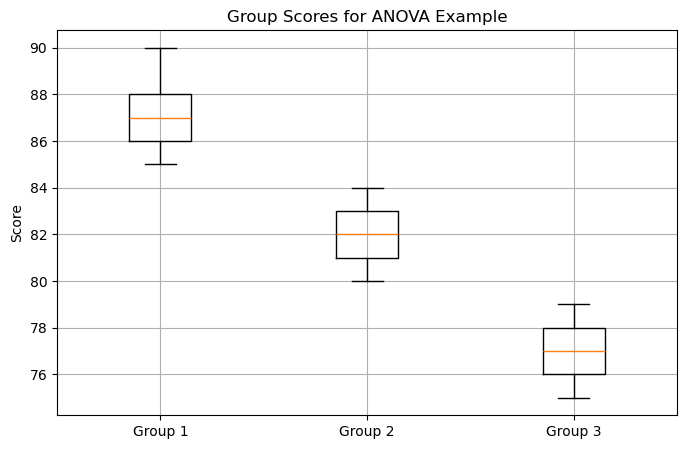

In [19]:
plt.figure(figsize=(8, 5))
plt.boxplot([anova_group_1, anova_group_2, anova_group_3], labels=["Group 1", "Group 2", "Group 3"])
plt.title("Group Scores for ANOVA Example")
plt.ylabel("Score")
plt.show()

# 7. Non-parametric tests

Parametric tests such as t-tests and ANOVA usually assume approximately normal errors and sometimes equal variances. Non-parametric tests are useful when those assumptions are questionable or when the data are ordinal.

Two common examples are:

1. **Kruskal-Wallis test:** a non-parametric alternative to one-way ANOVA.
2. **Mann-Whitney U test:** a non-parametric alternative to an independent two-sample t-test.

In [21]:
h_stat, p_value = kruskal(anova_group_1, anova_group_2, anova_group_3)
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4f}")

u_stat, p_value = mannwhitneyu(anova_group_1, anova_group_2, alternative="two-sided")
print(f"\nMann-Whitney U-statistic: {u_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Kruskal-Wallis H-statistic: 12.5000
P-value: 0.0019

Mann-Whitney U-statistic: 25.0000
P-value: 0.0079


# 8. Assumptions behind hypothesis tests

Hypothesis tests are not magic. Their reliability depends on assumptions about the data-generating process. Three especially important assumptions are:

1. **Normality:** errors or observations are approximately normally distributed.
2. **Stationarity:** time-series properties such as mean and variance are stable over time.
3. **Independence / i.i.d.:** observations do not mechanically depend on each other, and they come from the same distribution.

## 8.1 Normality

Many classical tests work best when the data are approximately normal. The Shapiro-Wilk test uses:

$$
H_0: \text{the data are normally distributed}
$$

A small p-value suggests rejecting normality.

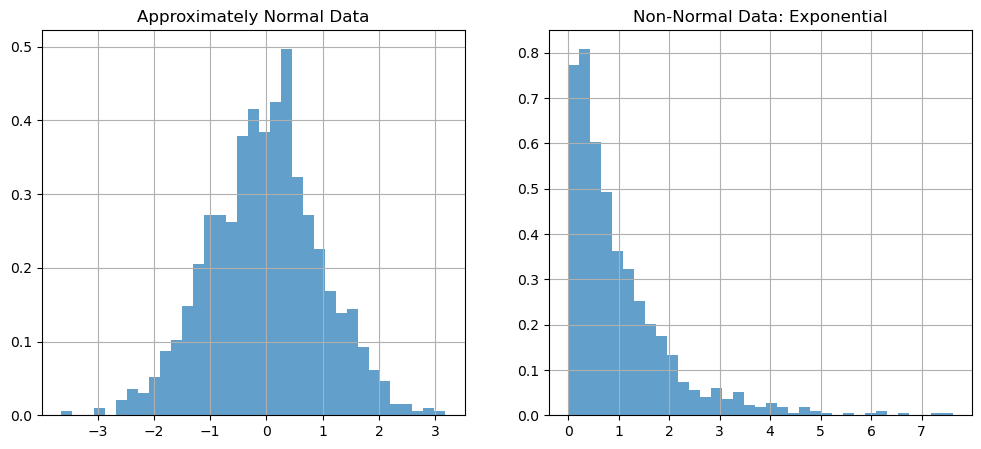

Normal data: Shapiro-Wilk statistic = 0.9988, p-value = 0.7576
Non-normal data: Shapiro-Wilk statistic = 0.7941, p-value = 9.497e-34


In [23]:
normal_data = rng.normal(0, 1, 1000)
non_normal_data = rng.exponential(1, 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(normal_data, bins=35, density=True, alpha=0.7)
axes[0].set_title("Approximately Normal Data")
axes[1].hist(non_normal_data, bins=35, density=True, alpha=0.7)
axes[1].set_title("Non-Normal Data: Exponential")
plt.show()

for name, sample in [("Normal data", normal_data), ("Non-normal data", non_normal_data)]:
    stat, p_value = stats.shapiro(sample)
    print(f"{name}: Shapiro-Wilk statistic = {stat:.4f}, p-value = {p_value:.4g}")

## 8.2 Stationarity

Stationarity is central in financial and macroeconomic time series. A weakly stationary process has a constant mean, constant variance, and autocovariances that depend only on lag length.

The Augmented Dickey-Fuller test is commonly used to test for a unit root:

$$
H_0: \text{the series has a unit root and is non-stationary}
$$

$$
H_1: \text{the series is stationary}
$$

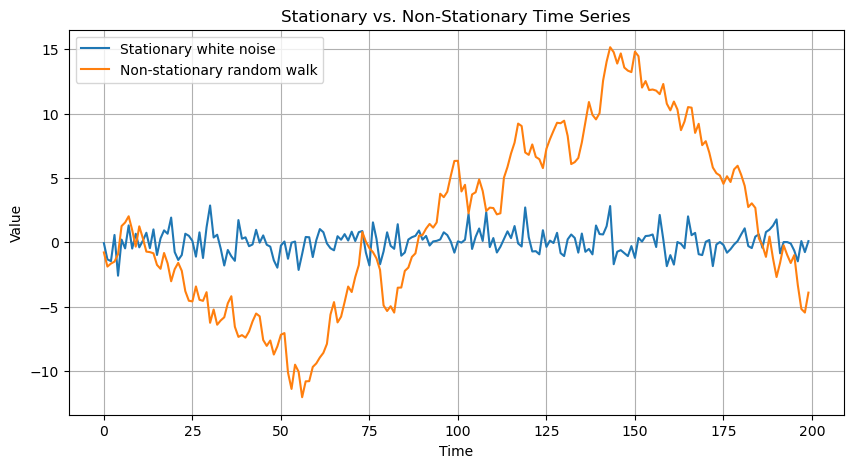

Stationary white noise: ADF statistic = -12.7702, p-value = 0.0000
Random walk: ADF statistic = -1.0623, p-value = 0.7299


In [25]:
stationary_series = rng.normal(0, 1, 200)
random_walk = np.cumsum(rng.normal(0, 1, 200))

plt.figure(figsize=(10, 5))
plt.plot(stationary_series, label="Stationary white noise")
plt.plot(random_walk, label="Non-stationary random walk")
plt.title("Stationary vs. Non-Stationary Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

for name, series in [("Stationary white noise", stationary_series), ("Random walk", random_walk)]:
    adf_stat, p_value, *_ = adfuller(series)
    print(f"{name}: ADF statistic = {adf_stat:.4f}, p-value = {p_value:.4f}")

## 8.3 Independence and i.i.d. data

The phrase **i.i.d.** means independent and identically distributed. It combines two claims:

1. **Independent:** one observation does not determine another.
2. **Identically distributed:** all observations come from the same distribution.

Autocorrelation is a common violation in time series. If errors are autocorrelated, standard errors may be wrong, and hypothesis tests may reject too often or not often enough.

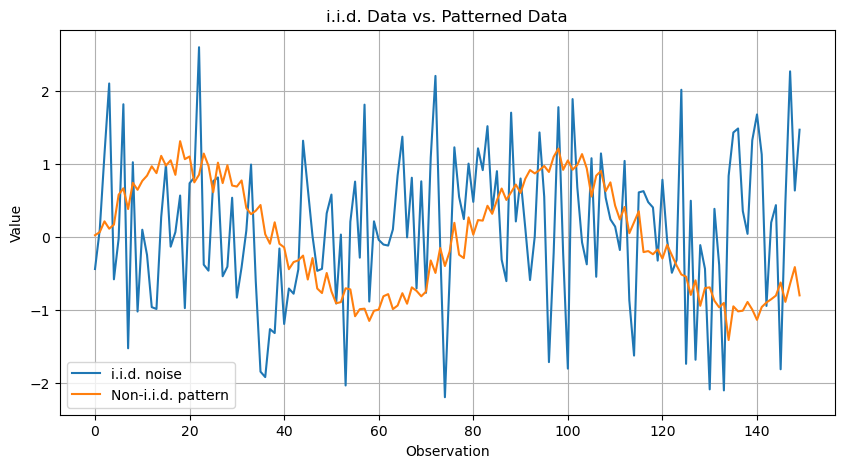

In [27]:
iid_data = rng.normal(0, 1, 150)
non_iid_data = np.sin(np.linspace(0, 12, 150)) + rng.normal(0, 0.15, 150)

plt.figure(figsize=(10, 5))
plt.plot(iid_data, label="i.i.d. noise")
plt.plot(non_iid_data, label="Non-i.i.d. pattern")
plt.title("i.i.d. Data vs. Patterned Data")
plt.xlabel("Observation")
plt.ylabel("Value")
plt.legend()
plt.show()

# 9. Power analysis

Before collecting data, researchers should ask whether their study is likely to detect an effect of economically or scientifically meaningful size.

Power depends on:

1. Effect size.
2. Sample size.
3. Significance level $\alpha$.
4. Noise in the data.

For a two-sample t-test, a common standardized effect size is Cohen's $d$:

$$
d = \frac{\mu_1 - \mu_2}{s_p}
$$

where $s_p$ is a pooled standard deviation. Larger effects are easier to detect. Larger samples also increase power.

In [29]:
effect_size = 0.5  # Cohen's d: often called a medium effect size
alpha = 0.05
desired_power = 0.80

analysis = TTestIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=desired_power)

print(f"Required sample size per group: {required_n:.2f}")

Required sample size per group: 63.77


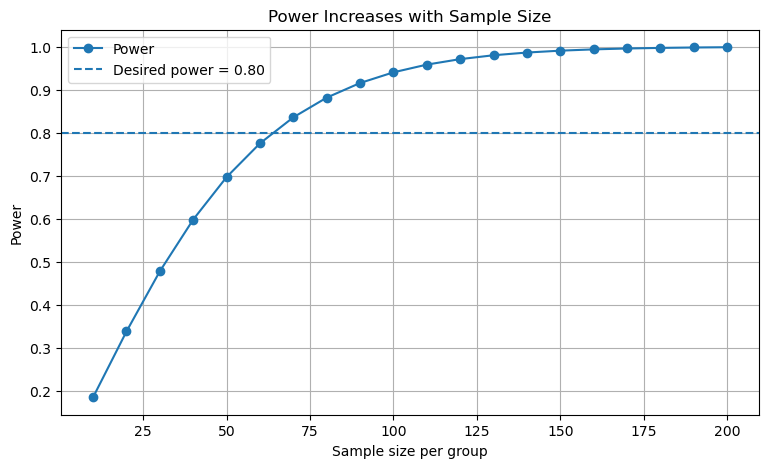

In [31]:
sample_sizes = np.arange(10, 201, 10)
powers = analysis.power(effect_size=effect_size, nobs1=sample_sizes, alpha=alpha)

plt.figure(figsize=(9, 5))
plt.plot(sample_sizes, powers, marker="o", label="Power")
plt.axhline(desired_power, linestyle="--", label="Desired power = 0.80")
plt.xlabel("Sample size per group")
plt.ylabel("Power")
plt.title("Power Increases with Sample Size")
plt.legend()
plt.show()

# 10. Designing and simulating an experiment

Suppose we want to test whether a new teaching method improves student test scores relative to a traditional method.

The research question is:

> Does the new teaching method lead to higher test scores than the traditional method?

The hypotheses are:

$$
H_0: \mu_{new} - \mu_{traditional} = 0
$$

$$
H_1: \mu_{new} - \mu_{traditional} > 0
$$

A clean experimental design should include:

1. A clear research question.
2. Random assignment.
3. Pre-specified sample size or power analysis.
4. A measurement plan.
5. A statistical test chosen before looking at the result.

In [33]:
# Use the power-analysis result to pick a sample size
n_per_group = int(np.ceil(required_n))
num_students = 2 * n_per_group

student_ids = np.arange(1, num_students + 1)
assignment = np.array(["Traditional"] * n_per_group + ["New"] * n_per_group)
rng.shuffle(assignment)

experiment = pd.DataFrame({
    "Student ID": student_ids,
    "Group": assignment
})

experiment.head()

,Student ID,Group
0,1,New
1,2,New
2,3,New
3,4,Traditional
4,5,Traditional


In [35]:
# Simulate outcomes: traditional mean = 70, new mean = 75, common standard deviation = 10
traditional_scores = rng.normal(loc=70, scale=10, size=(experiment["Group"] == "Traditional").sum())
new_scores = rng.normal(loc=75, scale=10, size=(experiment["Group"] == "New").sum())

experiment.loc[experiment["Group"] == "Traditional", "Test Score"] = traditional_scores
experiment.loc[experiment["Group"] == "New", "Test Score"] = new_scores

experiment.groupby("Group")["Test Score"].agg(["count", "mean", "std"])

,count,mean,std
Group,,,
New,64,74.123580,9.966085
Traditional,64,71.230358,10.619955


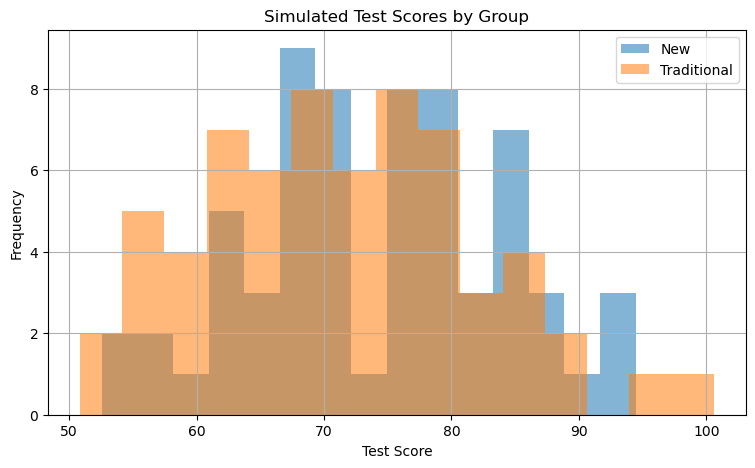

T-statistic: 1.5893
P-value: 0.0573


In [37]:
plt.figure(figsize=(9, 5))
for group_name, group_df in experiment.groupby("Group"):
    plt.hist(group_df["Test Score"], bins=15, alpha=0.55, label=group_name)
plt.title("Simulated Test Scores by Group")
plt.xlabel("Test Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

traditional_group = experiment.loc[experiment["Group"] == "Traditional", "Test Score"]
new_group = experiment.loc[experiment["Group"] == "New", "Test Score"]

# One-sided alternative: new group mean is greater than traditional group mean
result = ttest_ind(new_group, traditional_group, equal_var=False, alternative="greater")
print(f"T-statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

# 11. Bayesian comparison: beta-binomial example

Classical hypothesis testing asks whether data are unusually extreme under $H_0$. A Bayesian approach starts with a prior distribution, updates it with data, and computes posterior probabilities.

For binary success/failure data, the beta distribution is convenient. If:

$$
p \sim \operatorname{Beta}(\alpha, \beta)
$$

and we observe $s$ successes in $n$ trials, then the posterior is:

$$
p \mid \text{data} \sim \operatorname{Beta}(\alpha + s, \beta + n - s)
$$

We can then compute quantities such as:

$$
P(p_1 > p_2 \mid \text{data})
$$

This is a probability about parameters conditional on the observed data and prior, which is conceptually different from a p-value.

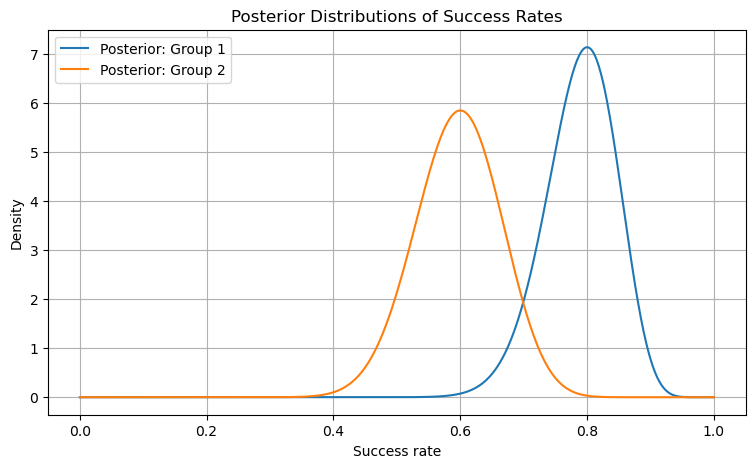

P(Group 1 success rate > Group 2 success rate | data): 0.9851


In [39]:
# Simulated success counts for two groups
success_group_1 = 40
total_group_1 = 50
success_group_2 = 30
total_group_2 = 50

# Uniform Beta(1, 1) priors
alpha_prior, beta_prior = 1, 1

alpha_post_1 = alpha_prior + success_group_1
beta_post_1 = beta_prior + (total_group_1 - success_group_1)

alpha_post_2 = alpha_prior + success_group_2
beta_post_2 = beta_prior + (total_group_2 - success_group_2)

x = np.linspace(0, 1, 1000)
posterior_1_pdf = beta.pdf(x, alpha_post_1, beta_post_1)
posterior_2_pdf = beta.pdf(x, alpha_post_2, beta_post_2)

plt.figure(figsize=(9, 5))
plt.plot(x, posterior_1_pdf, label="Posterior: Group 1")
plt.plot(x, posterior_2_pdf, label="Posterior: Group 2")
plt.title("Posterior Distributions of Success Rates")
plt.xlabel("Success rate")
plt.ylabel("Density")
plt.legend()
plt.show()

# Monte Carlo estimate of P(p1 > p2 | data)
posterior_draws_1 = rng.beta(alpha_post_1, beta_post_1, 100_000)
posterior_draws_2 = rng.beta(alpha_post_2, beta_post_2, 100_000)
prob_group_1_better = np.mean(posterior_draws_1 > posterior_draws_2)

print(f"P(Group 1 success rate > Group 2 success rate | data): {prob_group_1_better:.4f}")

# 12. Summary

This lecture introduced the main tools of hypothesis testing and experimental design.

Key takeaways:

1. A test statistic measures the distance between observed data and the null hypothesis.
2. The standard error measures how much sampling variability we expect in a statistic.
3. A p-value is computed under the assumption that $H_0$ is true.
4. Statistical significance is not the same thing as economic, financial, or practical significance.
5. Type I error is rejecting a true null; Type II error is failing to reject a false null.
6. Power is the probability of detecting an effect when the effect is real.
7. ANOVA, chi-square tests, and non-parametric tests extend the basic hypothesis-testing framework to other data structures.
8. Assumption checks matter because inference is only as good as the model behind it.
9. Good empirical work starts before the data are analyzed: it starts with design, randomization, and power.
10. Bayesian inference updates prior beliefs into posterior beliefs and answers a different kind of probability question.

# Practice problems

1. **One-sample t-test:** Generate 30 observations from a normal distribution with mean 10 and standard deviation 2. Test whether the mean differs from 9.5.

2. **Two-sample t-test:** Simulate two groups with different means. How large does the mean difference need to be before the p-value usually falls below 0.05?

3. **Power:** Repeat the power analysis for effect sizes $d = 0.2$, $d = 0.5$, and $d = 0.8$. What happens to the required sample size?

4. **ANOVA:** Simulate four groups and use one-way ANOVA to test whether their means differ.

5. **Non-parametric tests:** Generate skewed data using an exponential distribution and compare the result of a t-test to the Mann-Whitney U test.

6. **Bayesian comparison:** Change the prior from $\operatorname{Beta}(1,1)$ to $\operatorname{Beta}(10,10)$. How does the posterior probability change?